In [1]:
!pip install -q wfdb pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 107.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [2]:
import wfdb

record = wfdb.rdrecord(
    record_name="102147240",
    pn_dir=(
        "mimic-iv-ecg-demo/0.1/"
        "files/p10001725/s102147240"
    )
)

print("Shape:", record.p_signal.shape)
print("Sampling rate:", record.fs)
print("Leads:", record.sig_name)

Shape: (5000, 12)
Sampling rate: 500
Leads: ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


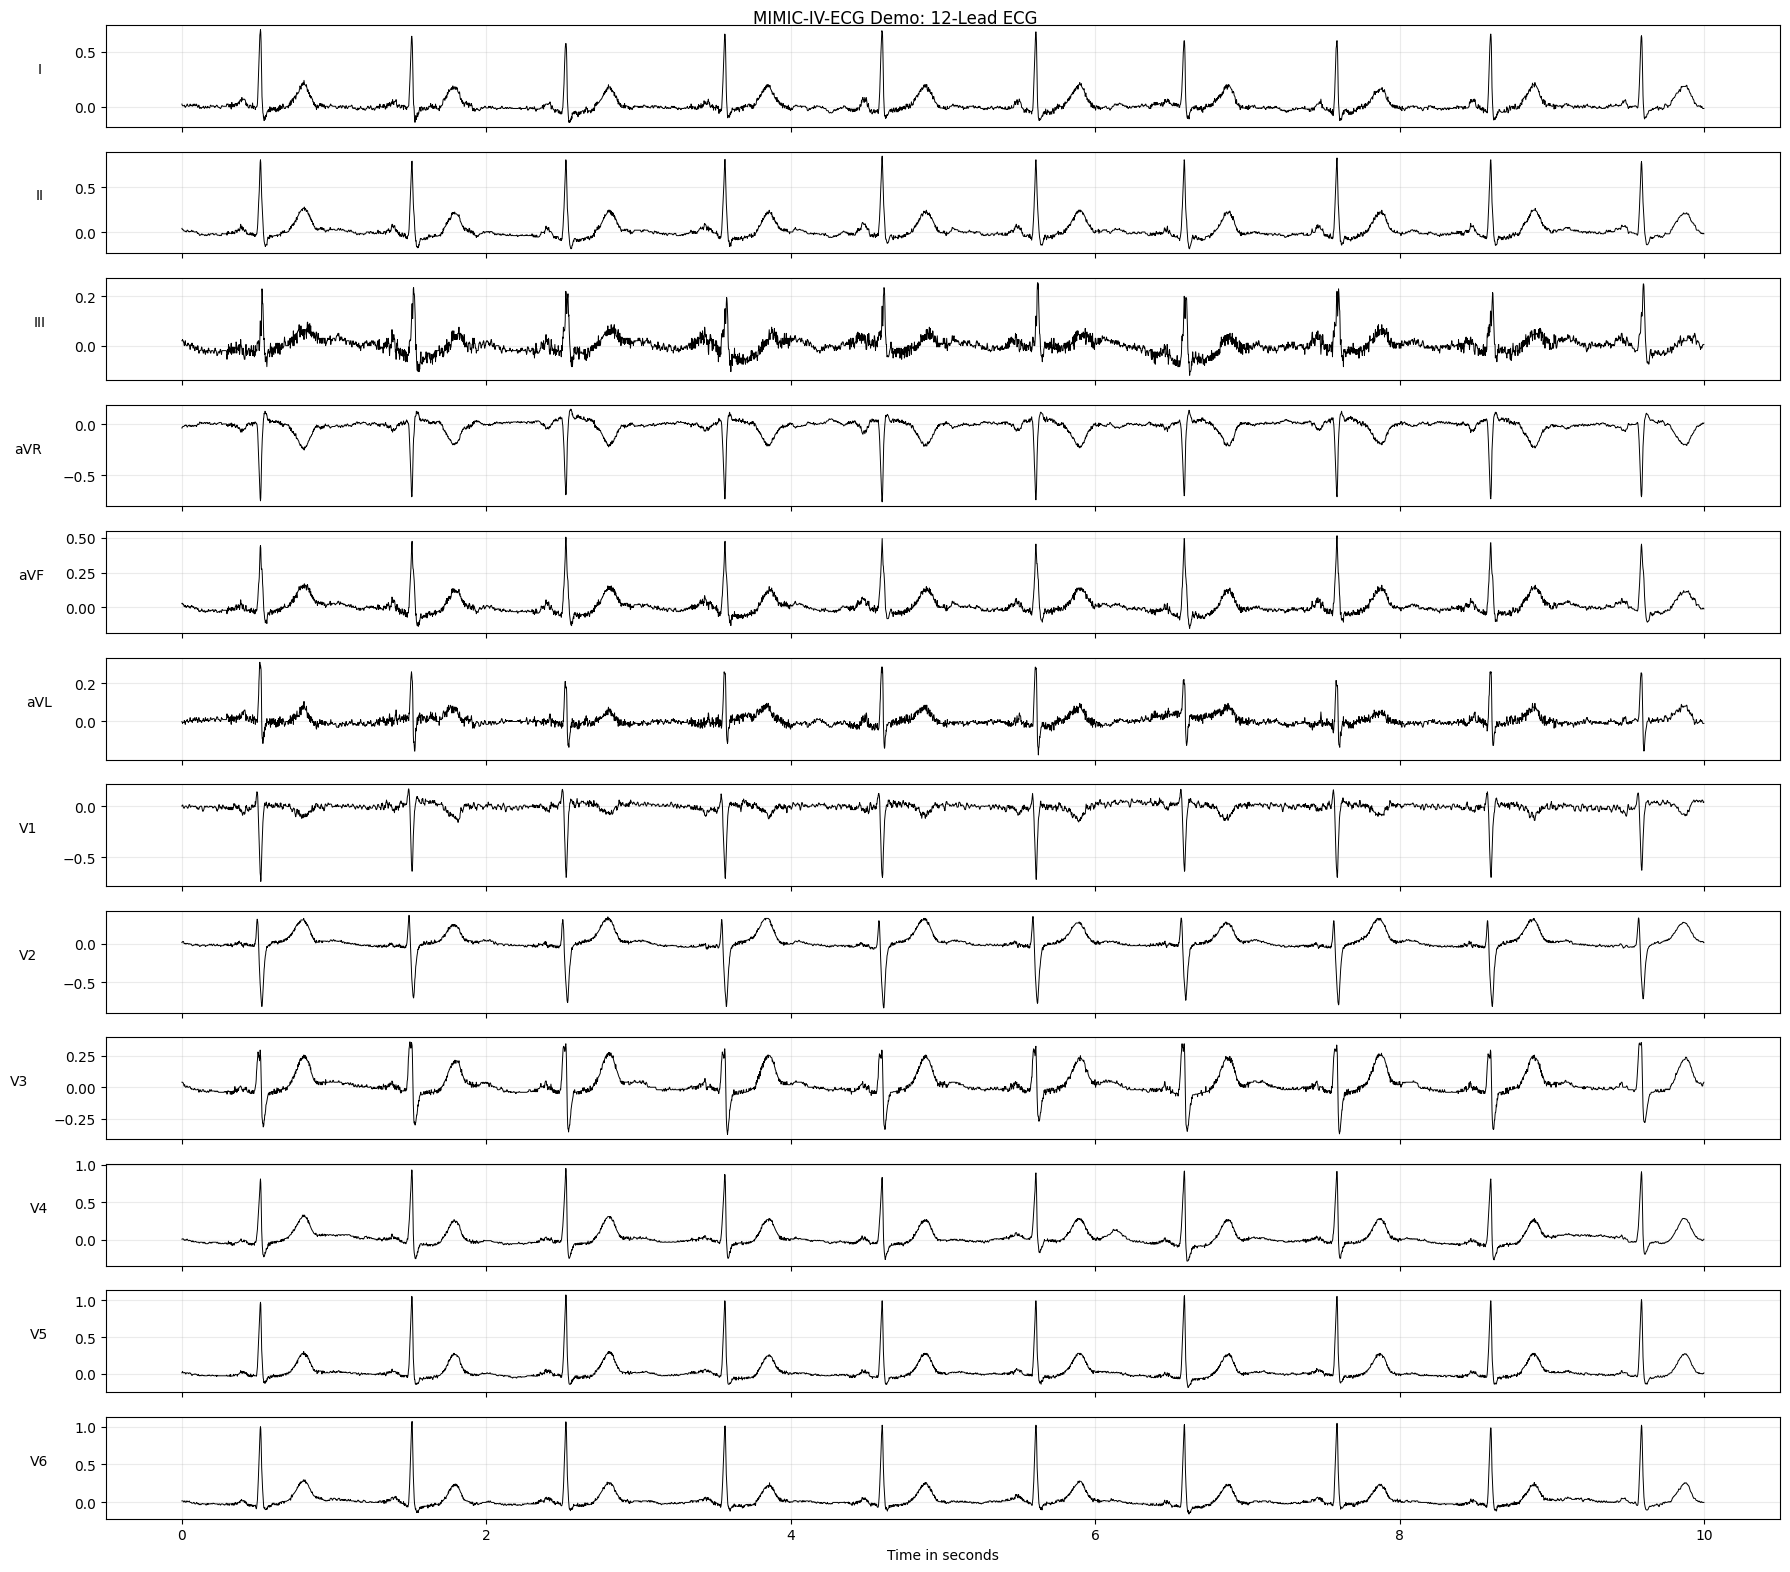

In [3]:
import numpy as np
import matplotlib.pyplot as plt

signal = record.p_signal
time = np.arange(signal.shape[0]) / record.fs

fig, axes = plt.subplots(
    12,
    1,
    figsize=(18, 16),
    sharex=True
)

for i, axis in enumerate(axes):
    axis.plot(time, signal[:, i], color="black", linewidth=0.7)
    axis.set_ylabel(record.sig_name[i], rotation=0, labelpad=25)
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Time in seconds")
fig.suptitle("MIMIC-IV-ECG Demo: 12-Lead ECG")
plt.tight_layout()
plt.show()